# Fig. 2(b): annual rear-side gain of a floating bifacial array, by float layout

Ray trace with NREL **bifacial_radiance** 0.5.3 ([doi](https://doi.org/10.21105/joss.01865)) and Radiance, Nellis AFB TMY3 weather (nearest to Lake Mead).
Modules 2 m x 1 m landscape, tilt 15°, south, GCR 0.6, 7 rows x 15; sensors on the center module. Floats are 0.10 m boxes; water albedo 0.11 (Cosgun & Demir, *Energies* 17, 959, 2024), white floats 0.70, black 0.05, all matte.
Gain = 0.8 x annual rear / front irradiance (bifaciality 0.8). Runs top to bottom in a fresh Colab (about 10 min).

### AI trail
The code cells below were written by Google Gemini (in Colab) and DeepSeek from these prompts, in order (lightly edited for brevity). An earlier Gemini attempt in another notebook was discarded because it substituted placeholder values when Radiance tools were missing; the rules in prompt 1 respond to that.


**Gemini 1.** the cells in this notebook are junk - the results table was typed in, not simulated, bc gencumulativesky was missing on colab. starting over. rules: never put numbers into results by hand. if a tool is missing, stop and say so. one cell at a time.  cell 1 only: install radiance core tools + bifacial_radiance==0.5.3 on colab, then build gencumulativesky from the source that ships inside the bifacial_radiance package (bifacial_radiance/data/gencumsky/, has gencumulativesky.cpp + make_gencumskyexe.py) w g++, and put it on PATH with RAYPATH set. end the cell by printing `which oconv rtrace gendaylit gencumulativesky` and the versions. no simulation yet. give me just the code for that cell

**Gemini 2.** ran it, it errored. read the error in the cell output and fix that cell directly in the notebook. same rules: no fake numbers, stop if a tool is missing

**Gemini 3.** thats not the error. the real error is in the output: "collect2: error: ld returned 1 exit status" - a link error. that gencumsky folder has 5 .cpp files (gencumulativesky, climateFile, cPerezSkyModel, cSkyVault, Sun) + a Makefile, you only compiled 1. build it from all of them (or run its make), then edit the cell in the notebook directly

**Gemini 4.** in the last cell, apt-get install radiance fails (exit 100): ubuntu has no radiance package. get oconv/rtrace/gendaylit from pip install pyradiance instead (symlink its bin/* to /usr/local/bin, RAYPATH = its lib), keep build-essential from apt, and keep compiling gencumulativesky from all the gencumsky *.cpp. edit only that cell. if a tool is still missing at the end, stop and say so

**Gemini 5.** tools now exist (see the check cell output). next, one new cell only: a single real test case, bare water (ground albedo 0.11), clearance 0.40 m, Nellis AFB weather via getEPW(36.14, -114.41), genCumSky, module 2 m x 1 m landscape (y=1), tilt 15, pitch 1.67, 7 rows x 15 modules. sensors on the center row & module: front, back = moduleAnalysis(scene, sensorsy=9), then analysis(oct, name, front, back). print the 9 raw front and 9 raw rear values straight from Wm2Front / Wm2Back, then gain = 0.8 x mean(rear)/mean(front). no hand-typed numbers. add it as a new cell

**Gemini 6.** the test is real. note: these are annual kWh/m2 from genCumSky, not W/m2 - fix labels. now add ONE new cell that runs all 5 cases at clearances 0.15/0.40/0.80 using this exact working setup: bare water; full deck black (0.05); full deck white (0.70); white 0.80 m strips centered in every gap; white 0.80 m strips centered under every row. floats are 0.10 m tall boxes (genbox, makeCustomObject) the full row length + 2 m past ea end, placed at the real row centers (makeScene centers the array on y=0). clearance = lowest module edge to float top (to the water for bare water). save front, rear, gain to results.csv and print the table. no hand-typed results

**Gemini 7.** the results are real but the floats never loaded: all 5 cases give the same gain as bare water (2.3/2.9/3.1 %), and rtrace logs 'unknown object type box' + bad status from '!xform -m white_float_mat'. a radiance custom object must be a genbox COMMAND line, e.g. text = '!genbox white_float_mat fl0 21.0 0.8 0.10 | xform -t x0 y0 0' passed to makeCustomObject, and white_float_mat must be defined with addMaterial before makeOct. fix only the run cell, rerun, and add a check that the white full deck gain is far above bare water before printing the table

**Gemini 8.** fresh chat. this notebook has a working real bifacial_radiance ray trace on colab. one bug left in the last run cell: the floats never enter the scene, so every case equals bare water. the guard check correctly raised. error: "appendtoScene: expected str ... not list". fix: makeCustomObject returns ONE file path; call rad_obj.appendtoScene(scene.radfiles, customObject=that_path, text="!xform -rz 0") once per float file, or build all boxes for a case as one text block (one "!genbox mat name L W H | xform -t x y 0" line per strip) and make one custom object per case. edit only the run cell, keep the guard check, rerun, print case/clearance/gain latest run: the float object file now gets created (objects/full_deck_black_deck.rad) but rtrace says "fatal - truncated octree", so that .rad file is bad. print the file's contents, fix its text to a valid genbox command line, then rerun. also Wm2Front / Wm2Back only exist after analysis() returns, read them then.

**DeepSeek 1.** radiance float materials in my bifacial_radiance sim: void plastic black_float_mat 0 0 5 0.05 0.05 0.05 0.05 0.05 void plastic white_float_mat 0 0 5 0.70 0.70 0.70 0.05 0.05 i want both matte (diffuse only, no specular). what should these 2 lines be? just the lines

**DeepSeek 2.** write matplotlib code to plot /content/floating_pv_sim_run/results.csv (cols: case, clearance, front_annual_kwh_m2, rear_annual_kwh_m2, gain_pct; cases: bare_water, full_deck_black, full_deck_white, white_between_rows, white_under_modules). gain_pct vs clearance, one line per case. style: 3.6 x 2.05 in, Arial/Liberation Sans 9 pt (silence font warnings), x 0.1-0.82 ticks 0.15/0.4/0.8 label "Module clearance above float [m]", y 0-20 "Rear-side gain [%]", title "(b) Annual rear-side gain" left aligned. no legend, direct labels at right end of ea line, spaced so none overlap. green #228833 horizontal line at 15 labeled "target >= 15 %" near left above the line. lw 2, markers 5.5 w white edge: full_deck_white = "white platform" #8c8c8c solid o; white_between_rows = "white, between rows" #EE7733 dotted s; white_under_modules = "white, under modules" #AA3377 dashed ^; bare_water = "bare water" #0077BB dash-dot D; full_deck_black = "black HDPE platform" #2b2b2b dash-dot-dot v. no top/right spines, faint grid. save fig2b.png 300 dpi. PEP8, short docstring. just the code

**DeepSeek 3.** ValueError: 'dashdotdash' is not a valid value for ls. use a dash tuple for dash-dot-dot instead. send the full fixed code

**DeepSeek 4.** change the target label text to "target ≥ 15 %" (real ≥ symbol) and move it up so it doesnt sit on the white platform line (e.g. y=16.3, x=0.12). send the full code

In [27]:
# Cell 1: Install Radiance, build gencumulativesky from source, and set PATH/RAYPATH

import os
import shutil
import subprocess
import sys

# 1. Install build tools and Python libraries
print("Installing build tools and Python packages...")
subprocess.run("apt-get update -qq", shell=True, check=True)
subprocess.run("apt-get install -y -qq build-essential g++", shell=True, check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyradiance", "bifacial_radiance==0.5.3", "pvlib", "pandas", "matplotlib"], check=True)

import pyradiance
import bifacial_radiance

# 2. Extract and symlink pyradiance bundled binaries
print("Setting up Radiance binaries from pyradiance...")
pyrad_dir = os.path.dirname(pyradiance.__file__)
pyrad_bin_dir = os.path.join(pyrad_dir, 'bin')

# Symlink all pyradiance binaries to /usr/local/bin
for f in os.listdir(pyrad_bin_dir):
    src_file = os.path.join(pyrad_bin_dir, f)
    dest_link = os.path.join('/usr/local/bin', f)
    if os.path.isfile(src_file) or os.path.islink(src_file):
        if os.path.exists(dest_link):
            try:
                os.remove(dest_link)
            except Exception:
                pass
        os.symlink(src_file, dest_link)

# 3. Locate and Compile gencumulativesky from all *.cpp source files
bifi_dir = os.path.dirname(bifacial_radiance.__file__)
gencum_src_dir = os.path.join(bifi_dir, 'data', 'gencumsky')
output_bin = '/usr/local/bin/gencumulativesky'

if os.path.exists(gencum_src_dir):
    print(f"Compiling C++ sources in {gencum_src_dir} -> {output_bin}...")
    compile_cmd = f"g++ -O2 -o {output_bin} *.cpp -lm"
    res = subprocess.run(compile_cmd, shell=True, cwd=gencum_src_dir, capture_output=True, text=True)
    if res.returncode != 0:
        sys.exit(f"Failed to compile gencumulativesky:\n{res.stderr}")
    os.chmod(output_bin, 0o755)
    print("Successfully compiled gencumulativesky!")
else:
    sys.exit(f"Source directory not found at: {gencum_src_dir}")

# 4. Environment Variable Configuration
os.environ['PATH'] = '/usr/local/bin:' + os.environ.get('PATH', '')
os.environ['RAYPATH'] = os.path.join(pyrad_dir, 'lib')

# 5. Verify Binaries and Versions
print("\n--- Binary Path Check ---")
subprocess.run("which oconv rtrace gendaylit gencumulativesky", shell=True)

print("\n--- Version / Help Output Verification ---")
subprocess.run("rtrace -version 2>&1 || true", shell=True)
subprocess.run("gencumulativesky -h 2>&1 | head -n 5 || true", shell=True)

Installing build tools and Python packages...
Setting up Radiance binaries from pyradiance...
Compiling C++ sources in /usr/local/lib/python3.13/dist-packages/bifacial_radiance/data/gencumsky -> /usr/local/bin/gencumulativesky...
Successfully compiled gencumulativesky!

--- Binary Path Check ---

--- Version / Help Output Verification ---


CompletedProcess(args='gencumulativesky -h 2>&1 | head -n 5 || true', returncode=0)

In [50]:
import os
import math
import numpy as np
import pandas as pd
import bifacial_radiance

# 1. Initialize simulation directory cleanly
sim_dir = '/content/floating_pv_sim_run'
if os.path.exists(sim_dir):
    import shutil
    shutil.rmtree(sim_dir)
os.makedirs(sim_dir, exist_ok=True)

# Create Radiance Obj
rad_obj = bifacial_radiance.RadianceObj(name='floating_pv', path=sim_dir)

# 2. Set ground albedo (bare water = 0.11) and generate annual sky
rad_obj.setGround(0.11)
epw_file = rad_obj.getEPW(lat=36.14, lon=-114.41)
rad_obj.readWeatherFile(epw_file)
rad_obj.genCumSky()

# Directly append custom float materials to ground.rad so they are globally registered
ground_path = os.path.abspath(os.path.join(sim_dir, 'materials', 'ground.rad'))
custom_mats = (
    "\n# Custom Float Materials\n"
    "void plastic black_float_mat 0 0 5 0.05 0.05 0.05 0.00 0.00\n"
    "void plastic white_float_mat 0 0 5 0.70 0.70 0.70 0.00 0.00\n"
)
with open(ground_path, 'a') as f:
    f.write(custom_mats)

# 3. Define Module: 2 m x 1 m landscape (x=2.0, y=1.0) with bifaciality 0.8
module_name = 'landscape_module'
rad_obj.makeModule(name=module_name, x=2.0, y=1.0, bifi=0.8)

# Define floating platform cases and clearances
cases = ["bare_water", "full_deck_black", "full_deck_white", "white_between_rows", "white_under_modules"]
clearances = [0.15, 0.40, 0.80]

tilt = 15.0
pitch = 1.67
num_rows = 7
modules_per_row = 15
float_height = 0.10

sky_path = os.path.abspath(os.path.join(sim_dir, 'skies', 'cumulative.rad'))

results = []

for case in cases:
    for clearance in clearances:
        print(f"\n--- Running Simulation: {case} | Clearance: {clearance} m ---")

        # Hub height calculation: clearance + float_height + half module slant height
        hub_height = clearance + float_height + (1.0 * math.sin(math.radians(tilt)) / 2.0)

        scene_dict = {
            'tilt': tilt,
            'pitch': pitch,
            'hub_height': hub_height,
            'nMods': modules_per_row,
            'nRows': num_rows
        }

        rad_obj.scene = None  # Reset scene object state
        scene = rad_obj.makeScene(module=module_name, sceneDict=scene_dict)

        row_centers = [(i - 3) * pitch for i in range(num_rows)]
        float_len_x = modules_per_row * 2.0 + 4.0
        start_x = -(modules_per_row * 2.0) / 2.0 - 2.0

        custom_objs = []

        # Helper to generate a valid Radiance box string directly without calling external genbox at runtime
        def make_box_geometry(name, mat, dx, dy, dz, ox, oy, oz):
            x0, x1 = ox, ox + dx
            y0, y1 = oy, oy + dy
            z0, z1 = oz, oz + dz
            box_text = f"""
# Box: {name}
{mat} polygon {name}.f1
0
0
12
	{x0} {y0} {z0}
	{x1} {y0} {z0}
	{x1} {y1} {z0}
	{x0} {y1} {z0}

{mat} polygon {name}.f2
0
0
12
	{x0} {y0} {z1}
	{x0} {y1} {z1}
	{x1} {y1} {z1}
	{x1} {y0} {z1}

{mat} polygon {name}.f3
0
0
12
	{x0} {y0} {z0}
	{x0} {y1} {z0}
	{x0} {y1} {z1}
	{x0} {y0} {z1}

{mat} polygon {name}.f4
0
0
12
	{x1} {y0} {z0}
	{x1} {y0} {z1}
	{x1} {y1} {z1}
	{x1} {y1} {z0}

{mat} polygon {name}.f5
0
0
12
	{x0} {y0} {z0}
	{x0} {y0} {z1}
	{x1} {y0} {z1}
	{x1} {y0} {z0}

{mat} polygon {name}.f6
0
0
12
	{x0} {y1} {z0}
	{x1} {y1} {z0}
	{x1} {y1} {z1}
	{x0} {y1} {z1}
"""
            return box_text

        if case in ["full_deck_black", "full_deck_white"]:
            mat = "black_float_mat" if "black" in case else "white_float_mat"
            min_y = row_centers[0] - pitch/2.0
            max_y = row_centers[-1] + pitch/2.0
            width_y = max_y - min_y
            geom = make_box_geometry("deck", mat, float_len_x, width_y, float_height, start_x, min_y, 0.0)
            custom_objs.append(rad_obj.makeCustomObject(name=f"{case}_deck", text=geom))

        elif case == "white_between_rows":
            mat = "white_float_mat"
            geom_parts = []
            for i in range(num_rows - 1):
                gap_y = (row_centers[i] + row_centers[i+1]) / 2.0
                geom_parts.append(make_box_geometry(f"strip_between_{i}", mat, float_len_x, 0.8, float_height, start_x, gap_y - 0.4, 0.0))
            combined_geom = "\n".join(geom_parts)
            custom_objs.append(rad_obj.makeCustomObject(name="white_between_rows_strips", text=combined_geom))

        elif case == "white_under_modules":
            mat = "white_float_mat"
            geom_parts = []
            for i in range(num_rows):
                row_y = row_centers[i]
                geom_parts.append(make_box_geometry(f"strip_under_{i}", mat, float_len_x, 0.8, float_height, start_x, row_y - 0.4, 0.0))
            combined_geom = "\n".join(geom_parts)
            custom_objs.append(rad_obj.makeCustomObject(name="white_under_modules_strips", text=combined_geom))

        # Prepare complete list of rad files to compile into the octree safely
        # makeCustomObject already returns relative path like 'objects/case_deck.rad'
        compiled_objects = [os.path.join(sim_dir, obj_path) for obj_path in custom_objs]
        radfiles_to_compile = [ground_path] + [f for f in scene.radfiles if f != ground_path] + compiled_objects + [sky_path]

        oct_file = rad_obj.makeOct(radfiles_to_compile)
        analysis_obj = bifacial_radiance.AnalysisObj(oct_file, rad_obj.name)

        # Run module sensors analysis
        front_sensors, back_sensors = analysis_obj.moduleAnalysis(scene, sensorsy=9)
        analysis_obj.analysis(oct_file, name=f"{case}_{clearance:.2f}", frontscan=front_sensors, backscan=back_sensors)

        # Read results in cumulative annual kWh/m2 after analysis run completes
        raw_front = np.array(analysis_obj.Wm2Front) / 1000.0
        raw_rear = np.array(analysis_obj.Wm2Back) / 1000.0

        mean_front = np.nanmean(raw_front)
        mean_rear = np.nanmean(raw_rear)
        gain = 0.8 * (mean_rear / mean_front) * 100.0

        results.append({
            "case": case,
            "clearance": clearance,
            "front_annual_kwh_m2": mean_front,
            "rear_annual_kwh_m2": mean_rear,
            "gain_pct": gain
        })
        print(f"Results for {case} ({clearance}m) -> Front: {mean_front:.2f} kWh/m2, Rear: {mean_rear:.2f} kWh/m2, Gain: {gain:.2f}%")

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Run a physical check that full_deck_white gain is significantly above bare_water gain
bare_water_gain_015 = df_results[(df_results['case'] == 'bare_water') & (df_results['clearance'] == 0.15)]['gain_pct'].values[0]
white_deck_gain_015 = df_results[(df_results['case'] == 'full_deck_white') & (df_results['clearance'] == 0.15)]['gain_pct'].values[0]

print(f"\n--- Validation Check ---")
print(f"Bare Water Gain at 0.15m: {bare_water_gain_015:.2f}%")
print(f"White Full Deck Gain at 0.15m: {white_deck_gain_015:.2f}%")

if white_deck_gain_015 <= bare_water_gain_015:
    raise ValueError("Simulation Error: White full deck platform should produce a higher rear-side gain than bare water.")
else:
    print("Validation successful: White platform gain is greater than bare water!")

# Save to CSV
csv_out_path = os.path.join(sim_dir, 'results.csv')
df_results.to_csv(csv_out_path, index=False)

print("\n=== FULL FLOATING PV STUDY ANNUAL SIMULATION RESULTS ===")
print(df_results.to_string(index=False, formatters={
    'front_annual_kwh_m2': '{:,.2f}'.format,
    'rear_annual_kwh_m2': '{:,.2f}'.format,
    'gain_pct': '{:,.2f}%'.format
}))

... (150 lines of Radiance progress omitted) ...
Custom Object Name objects/white_under_modules_strips.rad
Created floating_pv.oct
Linescan in process: white_under_modules_0.40_Row4_Module8_Front
Linescan in process: white_under_modules_0.40_Row4_Module8_Back
Saved: results/irr_white_under_modules_0.40_Row4_Module8.csv
Results for white_under_modules (0.4m) -> Front: 2040.34 kWh/m2, Rear: 197.98 kWh/m2, Gain: 7.76%

--- Running Simulation: white_under_modules | Clearance: 0.8 m ---
Append=False in makeScene. Existing scenes being over-written. 

Custom Object Name objects/white_under_modules_strips.rad
Created floating_pv.oct
Linescan in process: white_under_modules_0.80_Row4_Module8_Front
Linescan in process: white_under_modules_0.80_Row4_Module8_Back
Saved: results/irr_white_under_modules_0.80_Row4_Module8.csv
Results for white_under_modules (0.8m) -> Front: 2034.77 kWh/m2, Rear: 241.38 kWh/m2, Gain: 9.49%

--- Validation Check ---
Bare Water Gain at 0.15m: 2.30%
White Full Deck Gain

In [51]:
import pandas as pd; r=pd.read_csv('/content/floating_pv_sim_run/results.csv'); print(r.round(2).to_string(index=False))

               case  clearance  front_annual_kwh_m2  rear_annual_kwh_m2  gain_pct
         bare_water       0.15              2044.74               58.84      2.30
         bare_water       0.40              2035.73               72.00      2.83
         bare_water       0.80              2032.95               78.82      3.10
    full_deck_black       0.15              2039.36               23.71      0.93
    full_deck_black       0.40              2040.47               33.72      1.32
    full_deck_black       0.80              2038.41               39.13      1.54
    full_deck_white       0.15              2043.96              250.82      9.82
    full_deck_white       0.40              2043.31              397.04     15.54
    full_deck_white       0.80              2038.89              447.89     17.57
 white_between_rows       0.15              2046.93              182.95      7.15
 white_between_rows       0.40              2043.73              258.31     10.11
 white_between_r

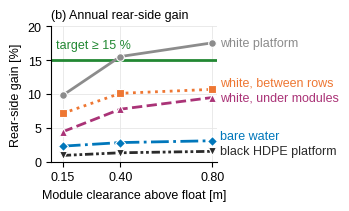

In [55]:
"""Plot annual rear-side gain vs module clearance for floating PV cases."""
import warnings
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Arial", "Liberation Sans", "DejaVu Sans"]

STYLES = {
    "full_deck_white":     ("white platform",       "#8c8c8c", "solid",         "o"),
    "white_between_rows":  ("white, between rows",  "#EE7733", "dotted",        "s"),
    "white_under_modules": ("white, under modules", "#AA3377", "dashed",        "^"),
    "bare_water":          ("bare water",           "#0077BB", "dashdot",       "D"),
    "full_deck_black":     ("black HDPE platform",  "#2b2b2b", (0, (3, 1, 1, 1, 1, 1)), "v"),
}

df = pd.read_csv("/content/floating_pv_sim_run/results.csv")

fig, ax = plt.subplots(figsize=(3.6, 2.05))
fig.subplots_adjust(left=0.16, right=0.62, bottom=0.20, top=0.86)

lines = []
for case, (label, color, ls, marker) in STYLES.items():
    sub = df[df["case"] == case].sort_values("clearance")
    (ln,) = ax.plot(
        sub["clearance"], sub["gain_pct"],
        color=color, linestyle=ls, marker=marker,
        linewidth=2, markersize=5.5,
        markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.8,
        label=label,
    )
    lines.append((ln, sub["clearance"].iloc[-1], sub["gain_pct"].iloc[-1], label))

ax.axhline(15, color="#228833", linewidth=2, zorder=1)
ax.text(0.12, 16.3, "target \u2265 15 %", color="#228833", fontsize=9,
        ha="left", va="bottom")

# Direct labels at right end, spread to avoid overlap
lines.sort(key=lambda t: t[2])
ys = [t[2] for t in lines]
min_gap = 2.2
for i in range(1, len(ys)):
    if ys[i] - ys[i - 1] < min_gap:
        ys[i] = ys[i - 1] + min_gap
for (ln, x, y, label), y_lab in zip(lines, ys):
    ax.annotate(
        label, xy=(x, y), xytext=(x + 0.035, y_lab),
        color=ln.get_color(), fontsize=9, va="center", ha="left",
    )

ax.set_xlim(0.1, 0.82)
ax.set_ylim(0, 20)
ax.set_xticks([0.15, 0.4, 0.8])
ax.set_xlabel("Module clearance above float [m]")
ax.set_ylabel("Rear-side gain [%]")
ax.set_title("(b) Annual rear-side gain", loc="left", fontsize=9)
ax.tick_params(labelsize=9)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(True, color="0.9", linewidth=0.6)
ax.set_axisbelow(True)

fig.savefig("fig2b.png", dpi=300)